# 日経平均株価 日足 メディアン統計

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime
import os

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
import yfinance as yf

from funcs.technical import calc_robust_bollinger

In [3]:
code = "N225"
symbol = "^%s" % code
yticker = yf.Ticker(symbol)

In [4]:
# 週足で過去 2 年分のデータを取得
df0 = yticker.history(period="2y", interval="1d")

# ローソク足のチャートには、そのうち過去 4ヶ月分のみ使用する
dt_last = df0.index[len(df0) - 1]
tdelta_6mo = datetime.timedelta(days=120)
df = df0[df0.index >= dt_last - tdelta_6mo]
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-11-04 00:00:00+09:00,52294.308594,52636.871094,51497.199219,51497.199219,190100000,0.0,0.0
2025-11-05 00:00:00+09:00,51291.390625,51422.421875,49073.578125,50212.269531,219700000,0.0,0.0
2025-11-06 00:00:00+09:00,50792.550781,51248.281250,50594.191406,50883.679688,171300000,0.0,0.0
2025-11-07 00:00:00+09:00,50524.308594,50642.789062,49640.558594,50276.371094,146700000,0.0,0.0
2025-11-10 00:00:00+09:00,50645.269531,50969.500000,50392.441406,50911.761719,129700000,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-26 00:00:00+09:00,58995.390625,59332.429688,58577.839844,58753.390625,155300000,0.0,0.0
2026-02-27 00:00:00+09:00,58606.031250,58924.171875,58130.570312,58850.269531,192400000,0.0,0.0
2026-03-02 00:00:00+09:00,57976.199219,58365.210938,57285.769531,58057.238281,162400000,0.0,0.0


In [5]:
dt = df.tail(1).index[0]
year_str = f"{dt.year:04d}"
month_str = f"{dt.month:02d}"
day_str = f"{dt.day:02d}"
output_path = os.path.join(year_str, month_str, day_str)
os.makedirs(output_path, exist_ok=True)
output_path

'2026/03/04'

## Moving Median

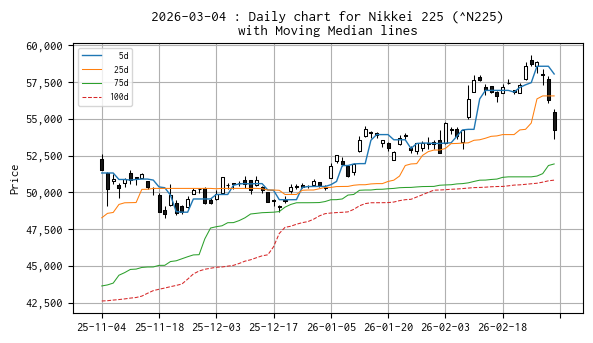

In [6]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig, ax = plt.subplots(figsize=(6, 3.5))


mm05 = df0["Close"].rolling(5).median()
mm25 = df0["Close"].rolling(25).median()
mm75 = df0["Close"].rolling(75).median()
mm100 = df0["Close"].rolling(100).median()

apds = [
    mpf.make_addplot(mm05[df.index], width=1, label="  5d", ax=ax),
    mpf.make_addplot(mm25[df.index], width=0.75, label=" 25d", ax=ax),
    mpf.make_addplot(mm75[df.index], width=0.75, label=" 75d", ax=ax),
    mpf.make_addplot(
        mm100[df.index],
        width=0.75,
        linestyle="dashed",
        label="100d",
        ax=ax,
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%y-%m-%d",
    addplot=apds,
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)

ax.grid()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_title(
    f"{dt.date()} : Daily chart for {yticker.info["longName"]} ({symbol})"
    "\nwith Moving Median lines"
)
ax.legend(loc="upper left", fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_path, f"daily_chart_median_{code}.png"))
plt.show()

In [7]:
df.tail(2)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-03 00:00:00+09:00,57729.800781,57890.761719,56091.539062,56279.050781,179000000,0.0,0.0
2026-03-04 00:00:00+09:00,55470.878906,55701.269531,53618.199219,54245.539062,0,0.0,0.0


## Robust Bollinger bands

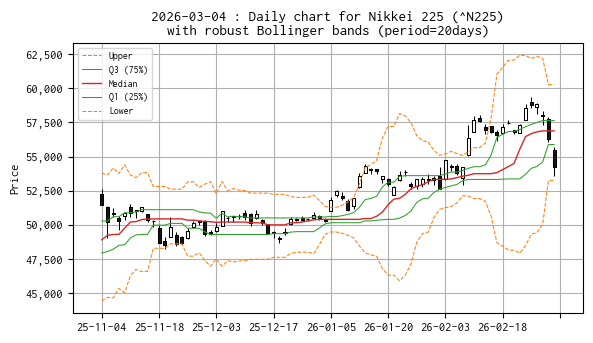

In [8]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 9

fig, ax = plt.subplots(figsize=(6, 3.5))

# Bollinger bands
period = 20
mv_median = df0["Close"].rolling(period).median()
mv_q1 = df0["Close"].rolling(period).quantile(0.25)
mv_q3 = df0["Close"].rolling(period).quantile(0.75)
mv_iqr = mv_q3 - mv_q1
mv_lower = mv_q1 - mv_iqr * 1.5
mv_upper = mv_q3 + mv_iqr * 1.5

apds = [
    mpf.make_addplot(
        mv_upper[df.index],
        width=0.75,
        color="C1",
        linestyle="dashed",
        label="Upper",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_q3[df.index],
        width=0.75,
        color="C2",
        linestyle="solid",
        label="Q3 (75%)",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_median[df.index],
        width=1.0,
        color="C3",
        linestyle="solid",
        label="Median",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_q1[df.index],
        width=0.75,
        color="C2",
        linestyle="solid",
        label="Q1 (25%)",
        ax=ax,
    ),
    mpf.make_addplot(
        mv_lower[df.index],
        width=0.75,
        color="C1",
        linestyle="dashed",
        label="Lower",
        ax=ax,
    ),
]

mpf.plot(
    df,
    type="candle",
    style="default",
    addplot=apds,
    datetime_format="%y-%m-%d",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)

ax.grid()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="best", fontsize=7)

try:
    ax.set_title(
        f"{dt.date()} : Daily chart for {yticker.info['longName']} ({symbol})"
        f"\nwith robust Bollinger bands (period={period}days)"
    )
except KeyError:
    ax.set_title(
        f"{dt.date()} : Daily chart for {symbol}\nwith robust Bollinger bands (period={period}days)"
    )

plt.tight_layout()
plt.savefig(
    os.path.join(output_path, f"daily_chart_bollinger_robust_{code}.png")
)
plt.show()

## ヒストグラムと Q-Q プロット

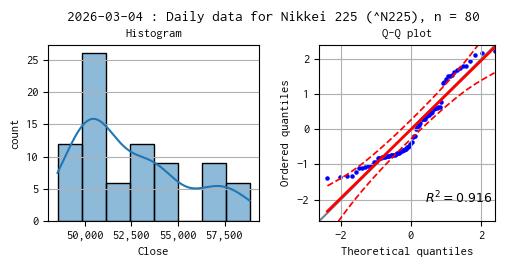

In [9]:
plt.rcParams["font.size"] = 9
fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))

sns.histplot(df["Close"], kde=True, ax=axes[0])

# ヒストグラム
axes[0].set_xlabel("Close")
axes[0].set_ylabel("count")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[0].grid(axis="y")
axes[0].set_title("Histogram", fontsize=9)

# Q-Q プロット
pg.qqplot(df["Close"], s=5, ax=axes[1])
axes[1].set_title("Q-Q plot", fontsize=9)
axes[1].grid()

plt.suptitle(
    f"{dt.date()} : Daily data for {yticker.info["longName"]} ({symbol}), n = {len(df)}",
    fontsize=11,
)
plt.subplots_adjust(top=0.84, bottom=0.135, wspace=0.2)
plt.savefig(
    os.path.join(output_path, f"daily_histogram_qqplot_{code}.png")
)
plt.show()